# Sesión de clase 08 · Ejercicio 2: BERTopic paso a paso

**BERTopic** (Grootendorst, 2022) separa dos problemas:

1. **Agrupar documentos por su significado:** embeddings → UMAP → HDBSCAN.
2. **Describir cada grupo con palabras:** CountVectorizer → c-TF-IDF →
   representación (KeyBERT, MMR o un LLM).

| Aspecto | LDA | BERTopic |
| --- | --- | --- |
| Representación | Conteo de palabras | Embeddings de Transformers |
| Sinónimos | No los reconoce | «demoró» y «tardó» quedan cerca |
| Número de tópicos | K fijo | Lo determina HDBSCAN |
| Asignación | Mezcla de tópicos por documento | Un tópico por documento |
| Documentos atípicos | Todos se asignan | Tópico −1 para el ruido |

Primero ejecutamos **cada módulo por separado** para ver qué hace, y luego los
unimos en un `BERTopic`. Corpus: los 135 comentarios de `data/comentarios.csv`.

**Etapas:** 1. Embeddings · 2. UMAP · 3. HDBSCAN · 4. c-TF-IDF · 5. BERTopic
completo · 6. Representaciones · 7. Ajuste (outliers y `min_cluster_size`) ·
Discusión.

In [1]:
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from umap import UMAP

pd.set_option("display.max_colwidth", 120)
SALIDAS = Path("../salidas")
SALIDAS.mkdir(exist_ok=True)

AZUL, ROJO, GRIS, TINTA = "#2a78d6", "#e34948", "#8a8985", "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRIS, "axes.labelcolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "figure.dpi": 110,
})

df = pd.read_csv("../data/comentarios.csv")
docs = df["texto"].tolist()
print(len(docs), "comentarios")

135 comentarios


## 1. Embeddings de los documentos

`paraphrase-multilingual-MiniLM-L12-v2`: 384 dimensiones, más de 50 idiomas,
corre en CPU. **Buena práctica:** calcular los embeddings **una vez**,
guardarlos (`embeddings.npy`) y pasarlos a `fit_transform(docs, embeddings)`
para no recalcularlos en cada prueba.

In [2]:
st = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

ruta_emb = SALIDAS / "embeddings.npy"
if ruta_emb.exists():
    embeddings = np.load(ruta_emb)
else:
    embeddings = st.encode(docs, show_progress_bar=True)
    np.save(ruta_emb, embeddings)
print(embeddings.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

(135, 384)


Los embeddings acercan textos con **el mismo significado aunque no compartan
palabras**: justo lo que LDA no podía hacer.

In [3]:
frases = ["El chat demoro media hora en responder",
          "El soporte tardo en contestar mi consulta",
          "Me cobraron dos veces en la tarjeta"]
sim = cosine_similarity(st.encode(frases))
pd.DataFrame(sim, index=frases, columns=["chat demoró", "soporte tardó", "cobraron dos veces"]).round(2)

,chat demoró,soporte tardó,cobraron dos veces
El chat demoro media hora en responder,1.00,0.34,0.24
El soporte tardo en contestar mi consulta,0.34,1.00,0.18
Me cobraron dos veces en la tarjeta,0.24,0.18,1.00


## 2. Reducción de dimensionalidad con UMAP

**Hipótesis del manifold:** los embeddings viven en 384 dimensiones, pero se
concentran cerca de una superficie de dimensión mucho menor. En 384
dimensiones las distancias entre puntos tienden a parecerse (**maldición de la
dimensionalidad**) y la densidad pierde contraste, lo que dificulta el
clustering.

UMAP construye un grafo de k vecinos en 384 d y busca una representación de
pocas dimensiones que preserve ese grafo.

| Parámetro | Valor | Efecto |
| --- | --- | --- |
| `n_neighbors` | 10 | Bajo: estructura local; alto: visión global |
| `n_components` | 5 | Dimensiones de salida para el clustering |
| `min_dist` | 0.0 | Puntos compactos que favorecen HDBSCAN |
| `metric` | `"cosine"` | La misma métrica de los embeddings |
| `random_state` | 42 | Resultados reproducibles |

Hacemos **dos reducciones**: a 5 d para agrupar y a 2 d solo para graficar.

In [4]:
umap_5d = UMAP(n_neighbors=10, n_components=5, min_dist=0.0,
               metric="cosine", random_state=42)
red_5d = umap_5d.fit_transform(embeddings)

red_2d = UMAP(n_neighbors=10, n_components=2, min_dist=0.0,
              metric="cosine", random_state=42).fit_transform(embeddings)
print("5 d:", red_5d.shape, "  2 d:", red_2d.shape)

5 d: (135, 5)   2 d: (135, 2)


### ¿Por qué no agrupar directamente en 384 d?

Comparamos la dispersión de las distancias: cuanto más se parecen todas las
distancias entre sí, menos contraste hay entre zonas densas y vacías. El
**coeficiente de variación** (desviación ÷ media) lo resume.

In [5]:
from scipy.spatial.distance import pdist

for nombre, datos, metrica in [("384 d (embeddings)", embeddings, "cosine"),
                               ("5 d (UMAP)", red_5d, "euclidean")]:
    d = pdist(datos, metric=metrica)
    print(f"{nombre:<20} coeficiente de variación de las distancias = {d.std() / d.mean():.2f}")

384 d (embeddings)   coeficiente de variación de las distancias = 0.21
5 d (UMAP)           coeficiente de variación de las distancias = 0.53


## 3. Clustering con HDBSCAN

- **Agrupa por densidad:** un clúster es una región con muchos puntos cercanos.
- **Construye una jerarquía** de densidades y conserva los clústeres más
  estables.
- **Define el número de tópicos:** no se fija K.
- **Separa el ruido:** los documentos aislados reciben la etiqueta −1.

### 3.1 HDBSCAN frente a k-means

Con datos simulados de dos medias lunas más puntos aislados:

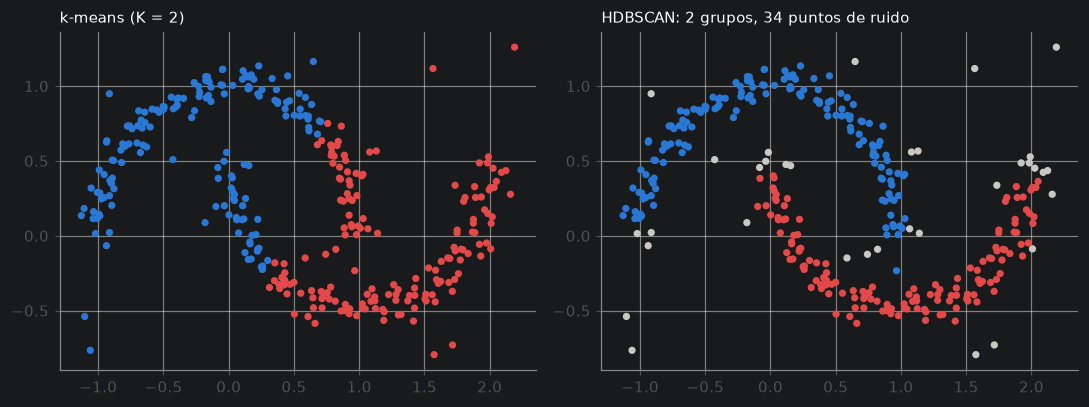

In [6]:
X_lunas, _ = make_moons(300, noise=0.06, random_state=42)
rng = np.random.default_rng(0)
X_lunas = np.vstack([X_lunas, rng.uniform([-1.2, -0.8], [2.2, 1.3], size=(25, 2))])

etq_km = KMeans(2, n_init=10, random_state=42).fit_predict(X_lunas)
etq_hd = HDBSCAN(min_cluster_size=15).fit_predict(X_lunas)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
paleta = np.array([AZUL, ROJO, "#3aa776", "#e0a030"])
for ax, etq, titulo in [(axes[0], etq_km, "k-means (K = 2)"),
                        (axes[1], etq_hd, f"HDBSCAN: {etq_hd.max() + 1} grupos, "
                                          f"{(etq_hd == -1).sum()} puntos de ruido")]:
    color = np.where(etq == -1, "#c9c8c4", paleta[np.clip(etq, 0, 3)])
    ax.scatter(X_lunas[:, 0], X_lunas[:, 1], c=color, s=14)
    ax.set_title(titulo, loc="left", fontsize=10)
plt.tight_layout()
plt.show()

k-means necesita K, supone grupos esféricos (corta las medias lunas) y
asigna **todos** los puntos, incluso el ruido. HDBSCAN encuentra las dos
formas y deja los puntos aislados en −1.

### 3.2 HDBSCAN sobre los comentarios

`min_cluster_size` es el tamaño mínimo de un tópico. Con 135 documentos
conviene un valor entre 4 y 8. Probamos varios:

In [7]:
filas = []
for mcs in [4, 5, 6, 8, 10]:
    etq = HDBSCAN(min_cluster_size=mcs).fit_predict(red_5d)
    tamanos = np.bincount(etq[etq >= 0])
    filas.append({"min_cluster_size": mcs, "grupos": etq.max() + 1,
                  "ruido (−1)": (etq == -1).sum(), "grupo más grande": tamanos.max(),
                  "tamaños": sorted(tamanos.tolist(), reverse=True)})
pd.DataFrame(filas).set_index("min_cluster_size")

,grupos,ruido (−1),grupo más grande,tamaños
min_cluster_size,,,,
4,9,26,34,"[34, 13, 12, 12, 11, 10, 7, 6, 4]"
5,5,7,65,"[65, 35, 12, 10, 6]"
6,4,21,64,"[64, 35, 8, 7]"
8,3,27,65,"[65, 34, 9]"
10,2,21,66,"[66, 48]"


Valores altos producen **pocos tópicos muy grandes** que mezclan temas.
Usamos `min_cluster_size=4`.

9 grupos y 26 documentos de ruido


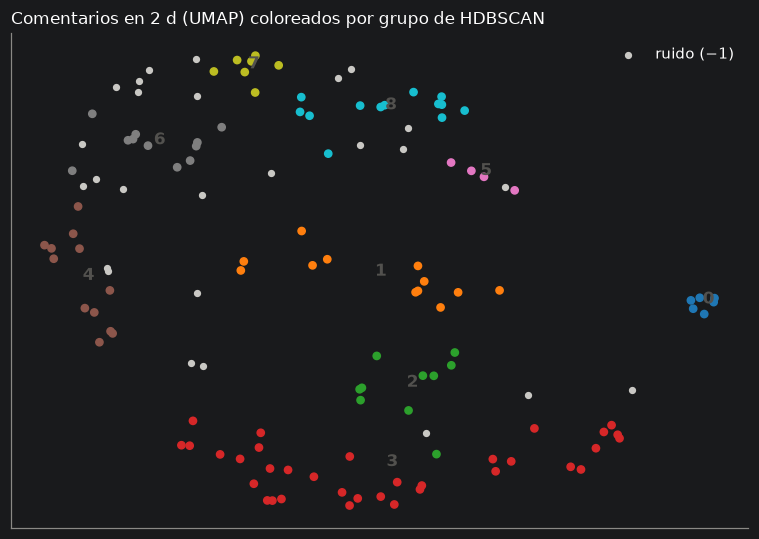

In [8]:
MIN_CLUSTER_SIZE = 4
etiquetas = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE).fit_predict(red_5d)
print(f"{etiquetas.max() + 1} grupos y {(etiquetas == -1).sum()} documentos de ruido")

fig, ax = plt.subplots(figsize=(7, 5))
ruido = etiquetas == -1
ax.scatter(red_2d[ruido, 0], red_2d[ruido, 1], c="#c9c8c4", s=14, label="ruido (−1)")
sc = ax.scatter(red_2d[~ruido, 0], red_2d[~ruido, 1], c=etiquetas[~ruido],
                cmap="tab10", s=22)
for g in range(etiquetas.max() + 1):
    cx, cy = red_2d[etiquetas == g].mean(axis=0)
    ax.text(cx, cy, str(g), fontsize=11, weight="bold", color=TINTA)
ax.set_title("Comentarios en 2 d (UMAP) coloreados por grupo de HDBSCAN", loc="left", fontsize=11)
ax.legend(frameon=False, loc="best")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

Antes de describir los grupos con palabras, leamos tres comentarios de cada
uno: ¿qué tienen en común?

In [9]:
(df.assign(grupo=etiquetas)
   .groupby("grupo").head(3)
   .sort_values("grupo")[["grupo", "calificacion", "texto"]])

,grupo,calificacion,texto
6,-1,4,El soporte me oriento bien sobre compatibilidad de accesorios con mi equipo.
16,-1,5,Me gusto poder guardar varias direcciones de envio para regalos.
15,-1,2,El proceso de cambio de producto por otro modelo fue mas lento de lo esperado.
81,0,2,"El diseno del sitio en el celular se ve desordenado en pantallas pequenas, algunos botones quedan superpuestos."
46,0,3,La app movil a veces se cierra sola cuando cambio de pantalla muy rapido. Fuera de eso funciona bien para navegar el...
33,0,3,"La app funciona correctamente la mayoria del tiempo, con alguna que otra pausa al cargar imagenes."
22,1,3,El diseno del sitio es agradable pero en modo oscuro algunos textos son dificiles de leer. Pequenos ajustes de contr...
19,1,4,"Buena experiencia general, aunque el sitio podria cargar mas rapido en horas pico."
5,1,5,Muy buena atencion personalizada cuando pregunte por disponibilidad de un modelo agotado.
0,2,5,El proceso de facturacion para empresa fue mas simple de lo que esperaba.


## 4. c-TF-IDF: palabras que distinguen a cada grupo

Se unen todos los documentos de un grupo en **un solo documento por grupo** y
se pondera cada término:

W(t, c) = tf(t, c) × log(1 + A / f(t))

- **tf(t, c):** frecuencia del término t en el grupo c.
- **f(t):** frecuencia de t en todos los grupos.
- **A:** promedio de palabras por grupo.

Una palabra **exclusiva y frecuente** en un grupo recibe peso alto; una palabra
**genérica** («buena», «proceso») recibe peso bajo aunque sea frecuente.

Las *stopwords* se quitan **solo aquí**: los embeddings se calcularon con el
texto completo.

In [10]:
def normalizar(texto):
    t = unicodedata.normalize("NFKD", texto.lower())
    return "".join(ch for ch in t if not unicodedata.combining(ch))


STOPWORDS_ES = sorted(set("""
a al algo algun alguna algunas alguno algunos ante antes aqui asi aun aunque
bajo bien cada casi como con contra cual cuando de del desde donde dos durante
e el ella ellas ellos en entre era eran es esa esas ese eso esos esta estaba
estaban estan estar este esto estos fue fueron ha habia han hasta hay he la las
le les lo los mas me mi mis mucho muy nada ni no nos o otra otras otro otros
para pero poco por porque que se ser si sin sobre solo su sus tambien tan tanto
te tiene todo todos tu tuve un una uno unos y ya yo vez veces mismo misma
son podria poder bastante
""".split()))

vectorizer = CountVectorizer(preprocessor=normalizar, stop_words=STOPWORDS_ES)

Calculamos c-TF-IDF **a mano** con la fórmula, para los grupos encontrados
(sin el ruido):

In [11]:
grupos = sorted(g for g in set(etiquetas) if g != -1)
doc_por_grupo = [" ".join(np.array(docs)[etiquetas == g]) for g in grupos]

conteos = vectorizer.fit_transform(doc_por_grupo).toarray()     # grupos × términos
terminos = vectorizer.get_feature_names_out()

tf = conteos
f = conteos.sum(axis=0)                 # frecuencia de cada término en todos los grupos
A = conteos.sum(axis=1).mean()          # promedio de palabras por grupo
ctfidf = tf * np.log(1 + A / f)

print(f"A = {A:.1f} palabras por grupo")
pd.DataFrame({f"grupo {g}": [terminos[i] for i in ctfidf[k].argsort()[::-1][:6]]
              for k, g in enumerate(grupos)})

A = 106.4 palabras por grupo


,grupo 0,grupo 1,grupo 2,grupo 3,grupo 4,grupo 5,grupo 6,grupo 7,grupo 8
0,app,sitio,registro,soporte,producto,claro,productos,tecnologia,compra
1,movil,buena,pago,correo,marcas,politicas,comparar,tienda,tienda
2,celular,experiencia,proceso,chat,stock,garantia,decidir,general,puntos
3,funciona,dificiles,cuenta,tardo,disponible,comprar,busqueda,buena,envio
4,rapido,oscuro,rapido,tiempo,variedad,financiamiento,revisar,preferida,pena
5,quedan,textos,simple,pedido,precio,explicarme,filtros,amplio,ultima


Comparemos en el grupo más grande el peso de una palabra exclusiva con el de
una genérica:

In [12]:
g = int(np.argmax(np.bincount(etiquetas[etiquetas >= 0])))
fila = grupos.index(g)
palabras = [terminos[i] for i in ctfidf[fila].argsort()[::-1][:3]] + ["buena", "experiencia", "general"]
pd.DataFrame([{"término": t, "tf en el grupo": tf[fila, j], "f en el corpus": f[j],
               "peso c-TF-IDF": round(ctfidf[fila, j], 1)}
              for t in palabras if t in terminos
              for j in [list(terminos).index(t)]]).set_index("término")

,tf en el grupo,f en el corpus,peso c-TF-IDF
término,,,
soporte,8,9,20.4
correo,7,9,17.9
chat,5,5,15.5
buena,0,13,0.0
experiencia,1,10,2.5
general,0,8,0.0


## 5. BERTopic completo

Unimos los módulos. Como fijamos la semilla de UMAP y pasamos los mismos
embeddings, BERTopic reproduce los grupos anteriores (renumerados por tamaño:
el tópico 0 es el más grande).

En `representation_model` pedimos **tres descripciones a la vez**: c-TF-IDF
(`Main`), `KeyBERTInspired` y `MaximalMarginalRelevance`.

In [13]:
def crear_modelo(min_cluster_size=MIN_CLUSTER_SIZE):
    return BERTopic(
        embedding_model=st,
        umap_model=UMAP(n_neighbors=10, n_components=5, min_dist=0.0,
                        metric="cosine", random_state=42),
        hdbscan_model=HDBSCAN(min_cluster_size=min_cluster_size, prediction_data=True),
        vectorizer_model=CountVectorizer(preprocessor=normalizar, stop_words=STOPWORDS_ES),
        representation_model={"KeyBERT": KeyBERTInspired(),
                              "MMR": MaximalMarginalRelevance(diversity=0.3)},
    )


topic_model = crear_modelo()
topicos, probs = topic_model.fit_transform(docs, embeddings)

info = topic_model.get_topic_info()
info["calif. promedio"] = info["Topic"].map(
    df.assign(t=topicos).groupby("t")["calificacion"].mean().round(1))
info[["Topic", "Count", "calif. promedio", "Representation"]]

,Topic,Count,calif. promedio,Representation
0,-1,26,4.0,"[producto, accesorios, soporte, buena, compatibilidad, reconoce, postventa, elegir, laptops, buscador]"
1,0,34,1.9,"[soporte, correo, chat, tardo, tiempo, pedido, proceso, dias, semana, sistema]"
2,1,13,4.1,"[compra, tienda, puntos, pena, programa, ultima, envio, realmente, experiencia, compras]"
3,2,12,3.8,"[sitio, buena, experiencia, general, virtual, modo, oscuro, leer, dificiles, rapidas]"
4,3,12,2.6,"[marcas, stock, producto, disponible, variedad, precio, compras, tiendas, productos, marcado]"
5,4,11,3.8,"[productos, comparar, decidir, busqueda, filtros, anteriores, revisar, tener, facil, marca]"
6,5,10,3.4,"[pago, registro, proceso, cuenta, crear, esperaba, simple, tomo, rapido, tarjeta]"
7,6,7,4.3,"[tecnologia, tienda, general, buena, amplio, preferida, catalogo, tiendas, volvere, diferencia]"
8,7,6,3.2,"[app, movil, celular, funciona, rapido, incluso, botones, carga, duplicadas, mayoria]"
9,8,4,5.0,"[politicas, claro, garantia, comprar, escondida, pequena, letra, financiamiento, explicarme, quedo]"


`get_document_info` da el tópico, la probabilidad y las palabras clave de
**cada documento**:

In [14]:
topic_model.get_document_info(docs)[["Document", "Topic", "Probability", "Representative_document"]].head(8)

,Document,Topic,Probability,Representative_document
0,El proceso de facturacion para empresa fue mas simple de lo que esperaba.,5,1.000000,False
1,"En general cumple lo que promete, ni mejor ni peor que otras tiendas de tecnologia que he probado.",6,1.000000,False
2,"Buena tienda en general, seguire comprando aqui mis proximos equipos.",6,0.590634,False
3,El envio internacional tardo mas dias de los indicados originalmente.,0,1.000000,False
4,El proceso de devolucion fue sencillo de iniciar aunque tomo unos dias en confirmarse.,5,1.000000,False
5,Muy buena atencion personalizada cuando pregunte por disponibilidad de un modelo agotado.,2,0.761485,False
6,El soporte me oriento bien sobre compatibilidad de accesorios con mi equipo.,-1,0.000000,False
7,El catalogo de marcas es decente aunque hay ciertos modelos que nunca llegan a tener stock.,3,1.000000,True


### Visualizaciones

Son gráficos interactivos de Plotly. Los guardamos también como HTML en
`salidas/`.

In [15]:
fig = topic_model.visualize_barchart(top_n_topics=10, n_words=6, width=230, height=230)
fig.write_html(SALIDAS / "bertopic_barchart.html", include_plotlyjs="cdn")
fig.show()

In [16]:
fig = topic_model.visualize_documents(docs, reduced_embeddings=red_2d, hide_annotations=True)
fig.write_html(SALIDAS / "bertopic_documentos.html", include_plotlyjs="cdn")
fig.show()

`visualize_hierarchy` muestra un dendrograma de los tópicos: ayuda a decidir
cuáles fusionar.

In [17]:
fig = topic_model.visualize_hierarchy()
fig.write_html(SALIDAS / "bertopic_jerarquia.html", include_plotlyjs="cdn")
fig.show()

## 6. Representaciones: c-TF-IDF, KeyBERTInspired y MMR

- **c-TF-IDF:** palabras con mayor peso.
- **KeyBERTInspired:** reordena las palabras por **similitud semántica** con
  los documentos representativos del tópico.
- **MMR (relevancia marginal máxima):** cada nueva palabra debe ser relevante
  para el tópico **y distinta** de las ya elegidas:

  MMR = argmax [ (1 − d) · sim(w, tópico) − d · máx sim(w, palabras elegidas) ]

  con d = `diversity` (0 a 1). Elimina variantes redundantes («cobro»,
  «cobraron», «cobros»).

In [18]:
reps = info.set_index("Topic").drop(index=-1)
pd.DataFrame({
    "c-TF-IDF": reps["Representation"].str[:6].str.join(", "),
    "KeyBERTInspired": reps["KeyBERT"].str[:6].str.join(", "),
    "MMR (0.3)": reps["MMR"].str[:6].str.join(", "),
}).rename_axis("tópico")

,c-TF-IDF,KeyBERTInspired,MMR (0.3)
tópico,,,
0,"soporte, correo, chat, tardo, tiempo, pedido","correo, plazo, correos, checkout, retraso, cancele","chat, proceso, semana, sistema, error, menos"
1,"compra, tienda, puntos, pena, programa, ultima","compras, tiendas, compradores, comprando, tienda, compra","compra, tienda, experiencia, compras, tiendas, impuestos"
2,"sitio, buena, experiencia, general, virtual, modo","navegar, experiencia, virtual, pagina, leer, sitio","experiencia, virtual, oscuro, leer, dificiles, rapidas"
3,"marcas, stock, producto, disponible, variedad, precio","compre, compras, tiendas, comprar, compro, stock","stock, producto, variedad, compras, tiendas, desconfianza"
4,"productos, comparar, decidir, busqueda, filtros, anteriores","comparar, productos, compras, busquedas, comparacion, filtros","productos, comparar, busqueda, filtros, revisar, tres"
5,"pago, registro, proceso, cuenta, crear, esperaba","credito, checkout, tarjeta, facturacion, registro, pago","pago, registro, cuenta, tarjeta, datos, opciones"
6,"tecnologia, tienda, general, buena, amplio, preferida","tiendas, tienda, tecnologia, recomendaria, electronica, preferida","tecnologia, tienda, catalogo, tiendas, diferencia, inteligentes"
7,"app, movil, celular, funciona, rapido, incluso","app, navegador, pantalla, pantallas, celular, botones","app, movil, celular, funciona, botones, duplicadas"
8,"politicas, claro, garantia, comprar, escondida, pequena","transparencia, garantia, notificaciones, transparente, claridad, correo","politicas, garantia, escondida, financiamiento, transparencia, transparente"


## 7. Ajuste en corpus pequeños

### 7.1 Documentos de ruido (tópico −1)

¿Qué comentarios quedaron como ruido?

In [19]:
df.assign(topico=topicos).query("topico == -1")[["calificacion", "texto"]].head(10)

,calificacion,texto
6,4,El soporte me oriento bien sobre compatibilidad de accesorios con mi equipo.
15,2,El proceso de cambio de producto por otro modelo fue mas lento de lo esperado.
16,5,Me gusto poder guardar varias direcciones de envio para regalos.
18,4,"Muy buena atencion cuando pregunte por la disponibilidad de un modelo agotado. Me avisaron apenas volvio a stock, ta..."
21,3,"El servicio postventa cumple lo basico, sin ser excepcional ni deficiente."
25,3,Las descripciones de producto son suficientes aunque podrian incluir mas fotos desde distintos angulos.
26,5,La comparacion de especificaciones tecnicas me ayudo muchisimo a elegir entre dos laptops similares. Es justo el tip...
27,5,El soporte tecnico me ayudo a elegir entre dos laptops segun mi uso real.
32,5,La confirmacion de pedido llega de inmediato al correo con todos los detalles.
36,5,Muy conforme con la rapidez para resolver un reclamo por un cargo duplicado.


`reduce_outliers` reasigna los documentos del tópico −1 al tópico más
parecido. Con la estrategia `"c-tf-idf"` compara el c-TF-IDF de cada documento
con el de los tópicos. Después hay que actualizar las representaciones con
`update_topics` (pasando de nuevo el `vectorizer_model`; si no, BERTopic usa
uno sin *stopwords*).

In [20]:
nuevos = topic_model.reduce_outliers(docs, topicos, strategy="c-tf-idf")
print("Documentos en −1 antes:", (np.array(topicos) == -1).sum())
print("Documentos en −1 después:", (np.array(nuevos) == -1).sum())

pd.crosstab(pd.Series(topicos, name="antes"), pd.Series(nuevos, name="después")).loc[[-1]]

Documentos en −1 antes: 26
Documentos en −1 después: 0


después,0,1,2,3,4,5,6,7,8
antes,,,,,,,,,
-1,5,3,1,7,3,2,2,0,3


Comparamos la calificación promedio por tópico antes y después de reasignar:

In [21]:
modelo_sin_ruido = crear_modelo()
modelo_sin_ruido.fit(docs, embeddings)
modelo_sin_ruido.update_topics(
    docs, topics=nuevos,
    vectorizer_model=CountVectorizer(preprocessor=normalizar, stop_words=STOPWORDS_ES),
    representation_model=KeyBERTInspired())

d = df.assign(antes=topicos, despues=nuevos)
pd.DataFrame({
    "comentarios antes": d["antes"].value_counts(),
    "comentarios después": d["despues"].value_counts(),
    "calif. antes": d.groupby("antes")["calificacion"].mean().round(2),
    "calif. después": d.groupby("despues")["calificacion"].mean().round(2),
    "palabras (KeyBERT, después)": pd.Series({t: ", ".join(w for w, _ in modelo_sin_ruido.get_topic(t)[:5])
                                              for t in set(nuevos)}),
}).rename_axis("tópico")

2026-10-06 17:42:04,912 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


,comentarios antes,comentarios después,calif. antes,calif. después,"palabras (KeyBERT, después)"
tópico,,,,,
-1,26,NaN,3.96,NaN,NaN
0,34,39.0,1.85,2.23,"checkout, plazo, correo, correos, cancele"
1,13,16.0,4.08,4.06,"compras, tiendas, compradores, comprando, tienda"
2,12,13.0,3.75,3.77,"virtual, navegar, pagina, experiencia, leer"
3,12,19.0,2.58,2.79,"compre, compras, tiendas, comprar, compro"
4,11,14.0,3.82,3.86,"buscador, comparar, comparacion, busca, busquedas"
5,10,12.0,3.40,3.33,"checkout, registro, credito, facturacion, tarjeta"
6,7,9.0,4.29,4.22,"tiendas, tienda, recomendaria, comprando, comprar"
7,6,6.0,3.17,3.17,"app, navegador, pantalla, pantallas, celular"


### 7.2 Variaciones de `min_cluster_size`

In [22]:
filas = []
for mcs in [4, 6, 10]:
    m = crear_modelo(mcs)
    t, _ = m.fit_transform(docs, embeddings)
    t = np.array(t)
    filas.append({"min_cluster_size": mcs, "tópicos": t.max() + 1, "ruido (−1)": (t == -1).sum(),
                  "tópicos (top-4 palabras KeyBERT)":
                      " | ".join(", ".join(w for w, _ in m.get_topic(k)[:4]) for k in range(t.max() + 1))})
pd.DataFrame(filas).set_index("min_cluster_size")

,tópicos,ruido (−1),tópicos (top-4 palabras KeyBERT)
min_cluster_size,,,
4,9,26,"soporte, correo, chat, tardo | compra, tienda, puntos, pena | sitio, buena, experiencia, general | marcas, stock, pr..."
6,4,21,"producto, tienda, tiendas, productos | correo, soporte, tiempo, chat | proceso, cuenta, pago, rapido | sitio, genera..."
10,2,21,"buena, producto, tienda, tiendas | proceso, correo, soporte, cuenta"


### 7.3 Fusionar tópicos

Si dos tópicos son redundantes, `merge_topics(docs, [[a, b]])` los une. Por
ejemplo, los dos más cercanos según el dendrograma:

In [23]:
dist = 1 - cosine_similarity(topic_model.topic_embeddings_[1:])   # sin el −1
np.fill_diagonal(dist, np.inf)
a, b = np.unravel_index(dist.argmin(), dist.shape)
print(f"Tópicos más cercanos: {a} y {b}")
for k in (a, b):
    print(f"  {k}: {', '.join(w for w, _ in topic_model.get_topic(k)[:6])}")

Tópicos más cercanos: 1 y 6
  1: compra, tienda, puntos, pena, programa, ultima
  6: tecnologia, tienda, general, buena, amplio, preferida


## Discusión

- ¿Qué tópicos de BERTopic **no aparecían con LDA**? ¿Cuáles se ven más
  fáciles de nombrar?
- Observen la calificación promedio por tópico: hay un tópico de quejas con
  calificación muy baja. Los embeddings no solo agrupan por **tema**, también
  por **tono** (queja, elogio). ¿Es eso deseable en un análisis de tópicos?
- ¿Qué comentarios quedan como ruido y por qué? ¿Tiene sentido forzar su
  reasignación?
- ¿Cómo cambia el número de tópicos con `min_cluster_size`?
- KeyBERTInspired frente a MMR: ¿cuál describe mejor cada tópico?

In [24]:
# Espacio para experimentar: cambien n_neighbors, min_cluster_size, min_samples,
# diversity de MMR o agreguen ngram_range=(1, 2) al CountVectorizer